## Insertion/Deletion Curve — Single-Sample Demo

Evaluating FIxLIP attribution quality via deletion curves and AID.

In [21]:
import torch
torch.cuda.empty_cache()

[No output generated]

In [22]:
import torch
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import shapiq
import src
from ImputerFactory import ImageImputerFactory
from Game import VisionLanguageGame

[No output generated]

### 1. Load model & data

In [23]:
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
model.to('cuda')
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [24]:
input_text = "black dog next to a yellow hydrant"
input_image = Image.open("assets/dog_and_hydrant.png")

[No output generated]

### 2. Build Imputer & Game

In [25]:
factory = ImageImputerFactory()
imputer = factory.build(model, processor, input_image, input_text)
game = VisionLanguageGame(imputer, batch_size=64)
n_total = game.n_players_image + game.n_players_text
print(f"n_img={game.n_players_image}, n_txt={game.n_players_text}, n_total={n_total}")

n_img=49, n_txt=8, n_total=57


In [26]:
# ── Build old-style game (src pipeline) for comparison ──
import src.game_huggingface
game_old = src.game_huggingface.VisionLanguageGame(
    model, processor,
    input_image=input_image,
    input_text=input_text,
    batch_size=64,
)

print(f"Old: n_img={game_old.n_players_image}, n_txt={game_old.n_players_text}, n_total={game_old.n_players}")
print(f"New: n_img={game.n_players_image}, n_txt={game.n_players_text}, n_total={game.n_players}")

Old: n_img=49, n_txt=8, n_total=57
New: n_img=49, n_txt=8, n_total=57


### 3. Compute FIxLIP interaction values

In [27]:
src.utils.set_seed(0)
fixlip = src.fixlip.FIxLIP(
    n_players_image=game.n_players_image,
    n_players_text=game.n_players_text,
    max_order=2,
    p=0.5,
    mode="banzhaf",
    random_state=0,
)
interaction_values = fixlip.approximate_crossmodal(game, budget=2**18)
print(interaction_values)

InteractionValues(
    index=FWBII, max_order=2, min_order=0, estimated=True, estimation_budget=262080,
    n_players=57, baseline_value=0.04800233333019677,
    Top 10 interactions:
        (54,): 2.338377952799431
        (33, 55): 1.7145613532852355
        (55, 56): 1.3486634306594993
        (28, 50): 1.313891933458639
        (29, 50): 1.3001633998542992
        (36, 50): 1.225290067052319
        (52,): -2.2740038152511235
        (56,): -2.310295994962091
        (50,): -4.703267009221505
        (55,): -6.742463020610707
)


### 4. Run Deletion Curves (MIF & LIF)

In [28]:
# Extract 1st-order attribution values
first_order = src.utils.convert_iv_to_first_order(interaction_values)
attr = first_order.get_n_order(1).values  # shape (n_total,)
attr_sorted = np.sort(attr)  # ascending

# MIF (Most Important First): remove high-attr → low-attr
# threshold descends from max → min
# attr <= max = all True (full coalition)
# attr <= min = only the single minimum-attr player is True (near empty)
coalition_mif = np.stack(
    [attr <= v for v in attr_sorted[::-1]] + [np.zeros(n_total, dtype=bool)]
)
pred_mif = game.value_function(coalition_mif)

# LIF (Least Important First): remove low-attr → high-attr  
# threshold ascends from min → max
# attr >= min = all True (full coalition)
# attr >= max = only the single maximum-attr player is True (near empty)
coalition_lif = np.stack(
    [attr >= v for v in attr_sorted] + [np.zeros(n_total, dtype=bool)]
)
pred_lif = game.value_function(coalition_lif)

print(f"MIF: {pred_mif[0]:.4f} (full) → {pred_mif[-1]:.4f} (empty)")
print(f"LIF: {pred_lif[0]:.4f} (full) → {pred_lif[-1]:.4f} (empty)")

<string>:12: UserWarning: Index FWBII is not a valid index as defined in {'JointSV', 'Co-Moebius', 'SGV', 'BV', 'FSII', 'SII', 'ELC', 'kADD-SHAP', 'BII', 'FBII', 'BGV', 'CHGV', 'Moebius', 'k-SII', 'EGV', 'CHII', 'SV', 'STII', 'IGV', 'EC'}. This might lead to unexpected behavior.


MIF: 33.9476 (full) → 22.8664 (empty)
LIF: 33.9476 (full) → 22.8664 (empty)


### 5. Normalize & compute AID

In [29]:
# Normalize both curves to [0, 1] using global min/max across BOTH curves
# This ensures no value exceeds [0, 1] — fixes the "LIF > 1" issue
v_min = min(pred_mif.min(), pred_lif.min())
v_max = max(pred_mif.max(), pred_lif.max())
print(f"v_min={v_min:.4f}, v_max={v_max:.4f}, range={v_max - v_min:.4f}")

mif_norm = (pred_mif - v_min) / (v_max - v_min)
lif_norm = (pred_lif - v_min) / (v_max - v_min)

# AID = mean area between LIF and MIF
aid = np.mean(lif_norm - mif_norm)
print(f"AID = {aid:.4f}  (0=random, larger=better, max≈1)")
print(f"mif_norm range: [{mif_norm.min():.4f}, {mif_norm.max():.4f}]")
print(f"lif_norm range: [{lif_norm.min():.4f}, {lif_norm.max():.4f}]")

v_min=16.6414, v_max=38.3940, range=21.7526
AID = 0.5712  (0=random, larger=better, max≈1)
mif_norm range: [0.0000, 0.7956]
lif_norm range: [0.0016, 1.0000]


### 6. Plot

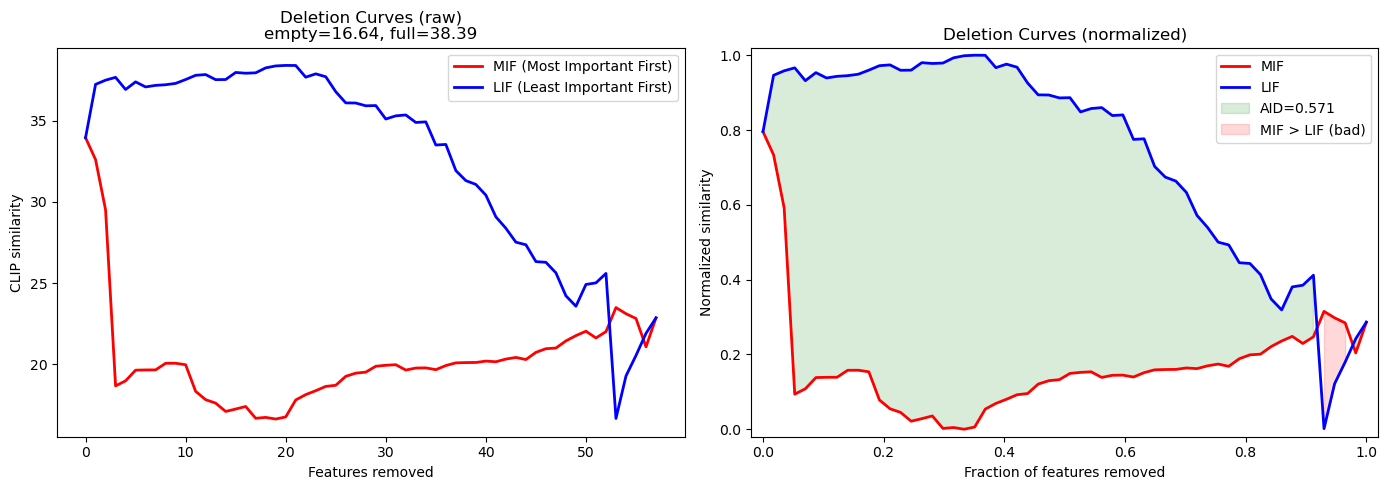

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: raw similarity curves ---
ax = axes[0]
x = np.arange(len(pred_mif))
ax.plot(x, pred_mif, 'r-', linewidth=2, label='MIF (Most Important First)')
ax.plot(x, pred_lif, 'b-', linewidth=2, label='LIF (Least Important First)')
ax.set_xlabel('Features removed')
ax.set_ylabel('CLIP similarity')
ax.set_title(f'Deletion Curves (raw)\nempty={v_min:.2f}, full={v_max:.2f}')
ax.legend()

# --- Right: normalized curves + AID fill ---
ax = axes[1]
x_frac = np.arange(len(mif_norm)) / (len(mif_norm) - 1)
ax.plot(x_frac, mif_norm, 'r-', linewidth=2, label='MIF')
ax.plot(x_frac, lif_norm, 'b-', linewidth=2, label='LIF')

# Fill only where LIF > MIF (typical case), otherwise fill with red warning
ax.fill_between(x_frac, lif_norm, mif_norm, where=(lif_norm >= mif_norm),
                alpha=0.15, color='green', label=f'AID={aid:.3f}')
ax.fill_between(x_frac, lif_norm, mif_norm, where=(lif_norm < mif_norm),
                alpha=0.15, color='red', label='MIF > LIF (bad)')

ax.set_xlabel('Fraction of features removed')
ax.set_ylabel('Normalized similarity')
ax.set_title('Deletion Curves (normalized)')
ax.legend()
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)  # give 2% headroom for curves touching edges

plt.tight_layout()
plt.show()

### Interpretation

- **MIF curve（红线）**：从完整输入开始，优先删最重要的特征。如果曲线从 0 开始就快速下跌 → 归因准确。
- **LIF curve（蓝线）**：从完整输入开始，优先删最不重要的特征。如果曲线保持高位直到最后才跌 → 归因准确。
- **AID（绿色区域）**：LIF − MIF 的平均面积。正值越大越好。
- **边界条件**：两条曲线最终在 empty coalition（-0.92 附近）汇合。

### 7. Numerical Validation: Old vs New Pipeline

Compare value_function outputs between old (`src.game_huggingface`) and new (`ImputerFactory + Game`) pipelines on the same coalitions.

In [31]:
# 1. Check player counts match
assert game_old.n_players == game.n_players, \
    f"Player count mismatch: old={game_old.n_players}, new={game.n_players}"
print("Player counts match:", game_old.n_players)

# 2. Compare empty / full coalition values
empty_old = game_old.empty_coalition_value
empty_new = game.normalization_value
print(f"Empty:  old={empty_old:.6f}, new={empty_new:.6f}, diff={abs(empty_old - empty_new):.2e}")

# Both pipelines should produce identically structured empty coalition
co_full = np.ones((1, game.n_players), dtype=bool)  # full coalition
co_empty = np.zeros((1, game.n_players), dtype=bool)  # empty coalition

full_old = game_old.value_function(co_full)[0]
full_new = game.value_function(co_full)[0]
empty_v_old = game_old.value_function(co_empty)[0]
empty_v_new = game.value_function(co_empty)[0]

print(f"Full:  old={full_old:.6f}, new={full_new:.6f}, diff={abs(full_old - full_new):.2e}")
print(f"Empty: old={empty_v_old:.6f}, new={empty_v_new:.6f}, diff={abs(empty_v_old - empty_v_new):.2e}")

# 3. Compare random coalitions
np.random.seed(42)
n_test = 200
test_coalitions = np.random.rand(n_test, game.n_players) > 0.5

values_old = game_old.value_function(test_coalitions)
values_new = game.value_function(test_coalitions)

diff = np.abs(values_old - values_new)
max_diff = diff.max()
mean_diff = diff.mean()
print(f"\n{n_test} random coalitions:")
print(f"  max_diff  = {max_diff:.6e}")
print(f"  mean_diff = {mean_diff:.6e}")

if max_diff < 1e-4:
    print("  → PASS (max_diff < 1e-4)")
elif max_diff < 1e-3:
    print(f"  → CLOSE (max_diff = {max_diff:.2e}, within 1e-3)")
else:
    print(f"  → FAIL (max_diff = {max_diff:.6e} > 1e-4)")
    # Show the worst coalition
    worst_idx = diff.argmax()
    print(f"  Worst coalition index: {worst_idx}")
    print(f"  old={values_old[worst_idx]:.6f}, new={values_new[worst_idx]:.6f}")

Player counts match: 57


Empty:  old=-0.000004, new=22.866415, diff=2.29e+01


Full:  old=33.947636, new=33.947636, diff=0.00e+00
Empty: old=22.866411, new=22.866411, diff=0.00e+00



200 random coalitions:
  max_diff  = 0.000000e+00
  mean_diff = 0.000000e+00
  → PASS (max_diff < 1e-4)


### 8. Reusable AID Pipeline Function

Encapsulate the full FIxLIP → AID pipeline so it can be called per image.

In [ ]:
def compute_aid_for_image(model, processor, input_image, input_text, 
                         budget=2**18, batch_size=64, seed=0):
    """
    Run the full FIxLIP → AID pipeline for a single image-text pair.
    
    Returns dict with keys: aid, pred_mif, pred_lif, mif_norm, lif_norm, 
                             v_min, v_max, n_players, interaction_values
    """
    # Build game (new ImputerFactory pipeline)
    factory = ImageImputerFactory()
    imputer = factory.build(model, processor, input_image, input_text)
    game = VisionLanguageGame(imputer, batch_size=batch_size)
    
    n_total = game.n_players_image + game.n_players_text
    
    # FIxLIP
    src.utils.set_seed(seed)
    fixlip = src.fixlip.FIxLIP(
        n_players_image=game.n_players_image,
        n_players_text=game.n_players_text,
        max_order=2, p=0.5, mode="banzhaf", random_state=seed,
    )
    iv = fixlip.approximate_crossmodal(game, budget=budget)
    
    # 1st-order attributions
    first_order = src.utils.convert_iv_to_first_order(iv)
    attr = first_order.get_n_order(1).values
    attr_sorted = np.sort(attr)
    
    # MIF & LIF curves
    coalition_mif = np.stack(
        [attr <= v for v in attr_sorted[::-1]] + [np.zeros(n_total, dtype=bool)]
    )
    pred_mif = game.value_function(coalition_mif)
    
    coalition_lif = np.stack(
        [attr >= v for v in attr_sorted] + [np.zeros(n_total, dtype=bool)]
    )
    pred_lif = game.value_function(coalition_lif)
    
    # Normalize
    v_min = min(pred_mif.min(), pred_lif.min())
    v_max = max(pred_mif.max(), pred_lif.max())
    mif_norm = (pred_mif - v_min) / (v_max - v_min)
    lif_norm = (pred_lif - v_min) / (v_max - v_min)
    aid = np.mean(lif_norm - mif_norm)
    
    return {
        "aid": aid,
        "pred_mif": pred_mif, "pred_lif": pred_lif,
        "mif_norm": mif_norm, "lif_norm": lif_norm,
        "v_min": v_min, "v_max": v_max,
        "n_players": n_total, "n_image": game.n_players_image, "n_text": game.n_players_text,
        "interaction_values": iv,
    }

print("Function defined: compute_aid_for_image(model, processor, image, text)")

### 9. Load MSCOCO Test Set (10 samples)

Stream images & captions from HuggingFace — no local storage needed (internet required).

In [ ]:
import datasets

dataset = datasets.load_dataset(
    "clip-benchmark/wds_mscoco_captions",
    split="test",
    streaming=True,
)

N_SAMPLES = 10
mscoco_samples = []
for i, d in enumerate(dataset):
    if i >= N_SAMPLES:
        break
    # Use first caption as the text
    captions = d['txt'].split("\n")
    mscoco_samples.append({
        "id": i,
        "image": d['jpg'],            # PIL Image
        "text": captions[0],           # best caption
    })

print(f"Loaded {len(mscoco_samples)} samples")
print(f"Sample 0: text = '{mscoco_samples[0]['text'][:80]}...'")

### 10. Run AID Pipeline on All 10 Samples

⚠ Cell takes ~5–10 min (budget=2^18 per image). Reduce budget for quick test.

In [ ]:
BUDGET = 2**18  # reduce to 2**15 for quick test (~30s/img)

results = {}
for s in mscoco_samples:
    print(f"[{s['id']+1}/{N_SAMPLES}] id={s['id']}  text='{s['text'][:60]}...'", flush=True)
    try:
        res = compute_aid_for_image(
            model, processor, s['image'], s['text'],
            budget=BUDGET, batch_size=64, seed=s['id'],
        )
        results[s['id']] = res
        print(f"  → n_players={res['n_players']}, AID={res['aid']:.4f}")
    except Exception as e:
        print(f"  → FAILED: {e}")
    torch.cuda.empty_cache()

print(f"\nDone. Successful: {len(results)}/{N_SAMPLES}")
aids = [r['aid'] for r in results.values()]
print(f"AID stats: mean={np.mean(aids):.4f}, std={np.std(aids):.4f}, "
      f"min={np.min(aids):.4f}, max={np.max(aids):.4f}")

### 11. Summary Plot — All Samples

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for idx, (img_id, res) in enumerate(results.items()):
    ax = axes[idx]
    x_frac = np.arange(len(res['mif_norm'])) / (len(res['mif_norm']) - 1)
    ax.plot(x_frac, res['mif_norm'], 'r-', linewidth=1.5, label='MIF')
    ax.plot(x_frac, res['lif_norm'], 'b-', linewidth=1.5, label='LIF')
    ax.fill_between(x_frac, res['lif_norm'], res['mif_norm'], 
                    where=(res['lif_norm'] >= res['mif_norm']),
                    alpha=0.12, color='green')
    ax.set_title(f"#{img_id}  AID={res['aid']:.3f}  ({res['n_players']}p)", fontsize=9)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    if idx >= 5:
        ax.set_xlabel('Fraction removed')
    if idx % 5 == 0:
        ax.set_ylabel('Norm. similarity')

# Hide unused subplots
for idx in range(len(results), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle(f'MSCOCO AID Curves — {len(results)} samples (banzhaf/0.5, order=2)', fontsize=13)
plt.tight_layout()
plt.show()